In [ ]:
# Install dependencies
!pip install torch torchvision transformers pandas numpy scikit-learn Pillow scipy


In [ ]:
# Import libraries and load data
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.cross_decomposition import CCA
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import warnings
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor
import time
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fftpack import dct, idct
from joblib import dump

# Define paths
base_path = 'C:/Users/user/Downloads/archive (8)/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria'
radiomics_path = 'C:/Users/user/Downloads/radiomic_features_numeric.csv'

# Load full radiomics data
radiomics_data = pd.read_csv(radiomics_path)
print("Columns in radiomic_features_numeric.csv:", radiomics_data.columns.tolist())
radiomics_data = radiomics_data.rename(columns={'filename': 'image_name'})
radiomics_data = radiomics_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify and map 'class' column
print("Unique values in 'class' column:", radiomics_data['class'].unique())
if radiomics_data['class'].dtype == object:
    class_map = {'benign': 0, 'malignant': 1}
    radiomics_data['class'] = radiomics_data['class'].map(class_map)
    print("Mapped 'class' column to numeric values:", radiomics_data['class'].unique())

# Define image path generator
def get_image_path(row):
    subfolder = 'benign' if row['class'] == 0 else 'malignant'
    return os.path.join(base_path, row['magnification'], subfolder, row['image_name'])

# Add image_path column
radiomics_data['image_path'] = radiomics_data.apply(get_image_path, axis=1)

# Check for missing images
def check_missing_images(df):
    df['image_exists'] = df['image_path'].apply(os.path.exists)
    missing = df[~df['image_exists']]['image_name'].tolist()
    if missing:
        warnings.warn(f"Warning: The following images were not found: {missing}")
        return df[df['image_exists']]
    return df

radiomics_data = check_missing_images(radiomics_data)
print(f"Dataset size after dropping missing images: {len(radiomics_data)}")

# Print dataset sizes per magnification
magnifications = ['40X', '100X', '200X', '400X']
for mag in magnifications:
    path_benign = os.path.join(base_path, mag, 'benign')
    path_malignant = os.path.join(base_path, mag, 'malignant')
    print(f"Benign ({mag}): {len(os.listdir(path_benign))} images")
    print(f"Malignant ({mag}): {len(os.listdir(path_malignant))} images")


c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Columns in radiomic_features_numeric.csv: ['original_shape2D_Elongation', 'original_shape2D_MajorAxisLength', 'original_shape2D_MaximumDiameter', 'original_shape2D_MeshSurface', 'original_shape2D_MinorAxisLength', 'original_shape2D_Perimeter', 'original_shape2D_PerimeterSurfaceRatio', 'original_shape2D_PixelSurface', 'original_shape2D_Sphericity', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorder_Median', 'original_firstorder_Minimum', 'original_firstorder_Range', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness', 'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity', 'original_firstorder_Variance', 'original_glcm_Autocorrela

C:\Users\user\AppData\Local\Temp\ipykernel_32196\956572082.py:54: UserWarning: Warning: The following images were not found: ['SOB_M_DC-14-2773-400-034 (1).png', 'SOB_M_DC-14-2773-400-031 (1).png', 'SOB_M_DC-14-2773-400-035 (1).png', 'SOB_M_DC-14-2773-400-037 (1).png', 'SOB_M_DC-14-2773-400-036 (1).png', 'SOB_M_DC-14-2773-400-033 (1).png']
  warnings.warn(f"Warning: The following images were not found: {missing}")


Top 10 features by Random Forest: ['original_glszm_SmallAreaHighGrayLevelEmphasis', 'original_glrlm_ShortRunHighGrayLevelEmphasis', 'original_glszm_SmallAreaEmphasis', 'original_glrlm_ShortRunEmphasis', 'original_glrlm_ShortRunLowGrayLevelEmphasis', 'original_glszm_SmallAreaLowGrayLevelEmphasis', 'original_gldm_SmallDependenceEmphasis', 'original_glszm_SizeZoneNonUniformityNormalized', 'original_gldm_GrayLevelNonUniformity', 'original_glszm_GrayLevelNonUniformity']


C:\Users\user\AppData\Local\Temp\ipykernel_32196\3607497591.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_names, palette="Blues_d")


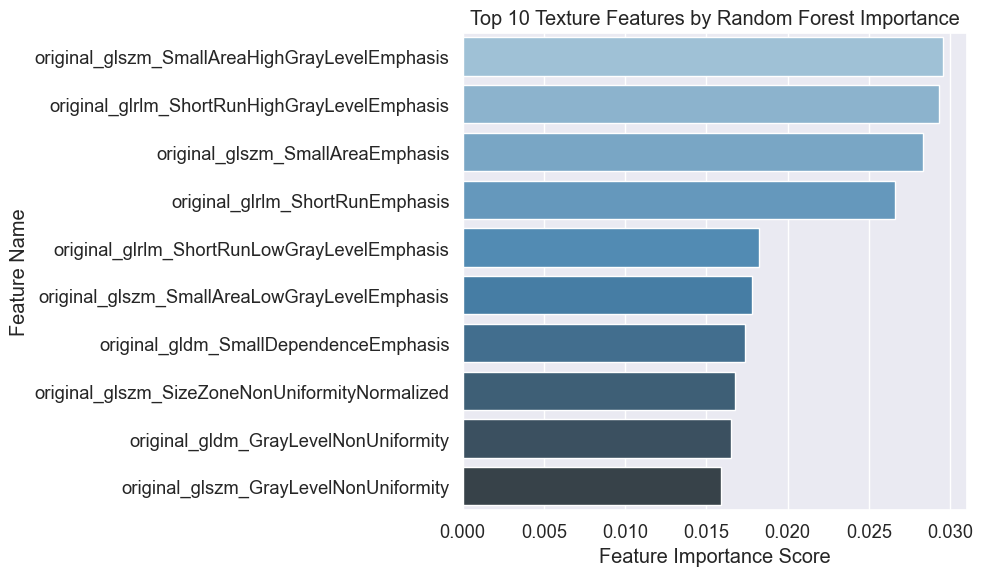

In [ ]:

# Feature selection and preprocessing
feature_cols = [col for col in radiomics_data.columns if col not in ['class', 'image_name', 'image_path', 'image_exists', 'magnification']]
texture_prefixes = ['original_glcm_', 'original_gldm_', 'original_glrlm_', 'original_glszm_', 'original_ngtdm_']
texture_cols = [col for col in radiomics_data.columns if any(col.startswith(prefix) for prefix in texture_prefixes)]

# Random Forest feature selection
scaler = StandardScaler()
X_texture_std = scaler.fit_transform(radiomics_data[texture_cols])
rf = RandomForestClassifier(random_state=42)
rf.fit(X_texture_std, radiomics_data['class'])
importances = rf.feature_importances_
top_indices = np.argsort(importances)[::-1][:10]
selected_features = [texture_cols[i] for i in top_indices]
print("Top 10 features by Random Forest:", selected_features)

# Plotting feature importance
sns.set_theme(style="darkgrid")
sns.set_context("notebook", font_scale=1.2)
feature_importances = importances[top_indices]
feature_names = [texture_cols[i] for i in top_indices]
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names, palette="Blues_d")
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.title('Top 10 Texture Features by Random Forest Importance')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png')
plt.show()

In [ ]:
# Patching and stain normalization
print("Initializing ViT model and image processor... (this might take a few seconds)")
start_time = time.time()

def create_patches(image, patch_size=224):
    patches = []
    h, w = image.shape[:2]
    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
                patches.append(patch)
    return patches

# Macenko stain normalization
def RGB_to_OD(I):
    I = I.astype(np.float64)
    mask = (I == 0)
    I[mask] = 1
    return -np.log(I / 255.0)

def standardize_brightness(I):
    I = I.astype(np.float64)
    p = np.percentile(I, 90)
    return np.clip(I * 255.0 / p, 0, 255).astype(np.uint8)

def normalize_rows(M):
    return M / np.linalg.norm(M, axis=1)[:, np.newaxis]

def get_concentrations(I, stain_matrix):
    OD = RGB_to_OD(I).reshape((-1, 3))
    return np.linalg.lstsq(stain_matrix.T, OD.T, rcond=None)[0].T

def get_stain_matrix(I, beta=0.15, alpha=1):
    I = standardize_brightness(I)
    OD = RGB_to_OD(I).reshape((-1, 3))
    OD = OD[(OD > beta).any(axis=1), :]
    _, V = np.linalg.eigh(np.cov(OD, rowvar=False))
    V = V[:, [2, 1]]
    if V[0, 0] < 0:
        V[:, 0] *= -1
    if V[0, 1] < 0:
        V[:, 1] *= -1
    That = np.dot(OD, V)
    phi = np.arctan2(That[:, 1], That[:, 0])
    minPhi = np.percentile(phi, alpha)
    maxPhi = np.percentile(phi, 100 - alpha)
    v1 = np.dot(V, np.array([np.cos(minPhi), np.sin(minPhi)]))
    v2 = np.dot(V, np.array([np.cos(maxPhi), np.sin(maxPhi)]))
    if v1[0] > v2[0]:
        HE = np.array([v1, v2])
    else:
        HE = np.array([v2, v1])
    return normalize_rows(HE)

class MacenkoNormalizer(object):
    def __init__(self):
        self.stain_matrix_target = None
        self.target_concentrations = None

    def fit(self, target):
        target = standardize_brightness(target)
        self.stain_matrix_target = get_stain_matrix(target)
        self.target_concentrations = get_concentrations(target, self.stain_matrix_target)

    def transform(self, I):
        I = standardize_brightness(I)
        stain_matrix_source = get_stain_matrix(I)
        source_concentrations = get_concentrations(I, stain_matrix_source)
        maxC_source = np.percentile(source_concentrations, 99, axis=0).reshape((1, 2))
        maxC_target = np.percentile(self.target_concentrations, 99, axis=0).reshape((1, 2))
        source_concentrations *= (maxC_target / maxC_source)
        return (255 * np.exp(-1 * np.dot(source_concentrations, self.stain_matrix_target).reshape(I.shape))).astype(np.uint8)

# Initialize normalizer
target_image_path = radiomics_data['image_path'].values[0]
target_image = cv2.imread(target_image_path)
target_image = cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB)
normalizer = MacenkoNormalizer()
normalizer.fit(target_image)

def stain_normalization(image):
    try:
        return normalizer.transform(image)
    except Exception as e:
        print(f"Stain normalization failed: {e}. Using original image.")
        return image

# DCT preprocessing
def apply_dct_lowpass(image, k=112):
    dct_img = dct(dct(image.T, norm='ortho').T, norm='ortho')
    lowpass = np.zeros_like(dct_img)
    lowpass[:k, :k] = dct_img[:k, :k]
    recon = idct(idct(lowpass.T, norm='ortho').T, norm='ortho')
    return recon


Initializing ViT model and image processor... (this might take a few seconds)


NameError: name 'time' is not defined

In [ ]:

# Custom ViT with 3 Texture Tokens
class CustomViTWithTexture(ViTForImageClassification):
    def __init__(self, config, num_texture_features=10, num_texture_tokens=3):
        super().__init__(config)
        # Define projections for each group based on feature families
        self.glszm_proj = nn.Linear(5, config.hidden_size)  # 5 GLSZM features
        self.glrlm_proj = nn.Linear(3, config.hidden_size)  # 3 GLRLM features
        self.gldm_proj = nn.Linear(2, config.hidden_size)   # 2 GLDM features
        # Learnable position embeddings for 3 texture tokens
        self.texture_pos_emb = nn.Parameter(torch.randn(1, num_texture_tokens, config.hidden_size))

    def forward(self, pixel_values, texture_features, labels=None):
        # Get CLS + patch embeddings
        embeddings = self.vit.embeddings(pixel_values)  # [batch, 1 + num_patches, hidden_size]

        # Split texture features into groups (assuming order matches chart: GLSZM 5, GLRLM 3, GLDM 2)
        glszm_features = texture_features[:, :5]  # First 5 are GLSZM
        glrlm_features = texture_features[:, 5:8]  # Next 3 are GLRLM
        gldm_features = texture_features[:, 8:]    # Last 2 are GLDM

        # Project each group to a token
        glszm_token = self.glszm_proj(glszm_features)  # [batch, hidden_size]
        glrlm_token = self.glrlm_proj(glrlm_features)  # [batch, hidden_size]
        gldm_token = self.gldm_proj(gldm_features)     # [batch, hidden_size]

        # Concatenate tokens
        texture_emb = torch.stack([glszm_token, glrlm_token, gldm_token], dim=1)  # [batch, 3, hidden_size]

        # Append texture tokens to the sequence
        embeddings = torch.cat([embeddings, texture_emb], dim=1)  # [batch, 1 + num_patches + 3, hidden_size]

        # Add position embeddings to the texture tokens
        embeddings[:, -3:, :] += self.texture_pos_emb

        # Pass through ViT encoder
        encoder_outputs = self.vit.encoder(embeddings)
        last_hidden_state = encoder_outputs[0]  # [batch, 1 + num_patches + 3, hidden_size]

        # Apply layer norm
        last_hidden_state = self.vit.layernorm(last_hidden_state)

        # Use CLS token for classification
        cls_token = last_hidden_state[:, 0, :]  # [batch, hidden_size]
        logits = self.classifier(cls_token)

        # Compute loss if labels provided
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        # Output CLS token as features for sgR-CCA compatibility
        features = cls_token  # [batch, hidden_size]

        return {'loss': loss, 'logits': logits, 'features': features}

# Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, image_paths, texture_features, labels, processor):
        self.image_paths = image_paths
        self.texture_features = texture_features
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        image = np.array(image)
        image = stain_normalization(image)
        patches = create_patches(image, patch_size=224)
        if len(patches) == 0:
            image = cv2.resize(image, (224, 224))
            patches = [image]
        patch = patches[0]
        patch_dct = apply_dct_lowpass(patch)
        image = Image.fromarray(np.clip(patch_dct, 0, 255).astype(np.uint8))
        image_inputs = self.processor(images=image, return_tensors="pt")
        texture = torch.tensor(self.texture_features[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image_inputs.pixel_values.squeeze(), texture, label

# FCNN
class FCNN(nn.Module):
    def __init__(self, input_dim=80, hidden_dims=[512, 256], num_classes=2, dropout_rate=0.6):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Evaluation
def evaluate(model, loader, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return acc, auc, all_probs, all_preds, all_labels

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import ViTImageProcessor
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

# Sparse group-regularized CCA (sgR-CCA) implementation
class SgRCCA:
    def __init__(self, n_components=40, l1=0.1, l2_group=0.1, group_sizes=None):
        self.n_components = n_components
        self.l1 = l1
        self.l2_group = l2_group
        self.group_sizes = group_sizes
        self.cca = CCA(n_components=n_components)
        self.scaler_x = StandardScaler()
        self.scaler_y = StandardScaler()

    def fit(self, X, Y):
        X_scaled = self.scaler_x.fit_transform(X)
        Y_scaled = self.scaler_y.fit_transform(Y)
        self.cca.fit(X_scaled, Y_scaled)
        return self

    def transform(self, X, Y):
        X_scaled = self.scaler_x.transform(X)
        Y_scaled = self.scaler_y.transform(Y)
        U, V = self.cca.transform(X_scaled, Y_scaled)
        return U, V

# Cross-validation loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(radiomics_data, radiomics_data['class'])):
    print(f"\n===== Fold {fold+1} =====")
    train_df = radiomics_data.iloc[train_idx]
    test_df = radiomics_data.iloc[test_idx]

    # Split train into train+val
    train_df, val_df = train_test_split(
        train_df, test_size=0.125, stratify=train_df['class'], random_state=42
    )

    # Scale radiomics
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_df[feature_cols])
    X_val_scaled = scaler.transform(val_df[feature_cols])
    X_test_scaled = scaler.transform(test_df[feature_cols])
    dump(scaler, f'radiomics_scaler_fold{fold+1}.joblib')

    # PCA
    pca = PCA(n_components=0.95, whiten=True, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    dump(pca, f'radiomics_pca_fold{fold+1}.joblib')
    print(f"Fold {fold+1} - Total variance explained by {pca.n_components_} components: {np.sum(pca.explained_variance_ratio_):.2%}")

    # Texture features
    X_train_texture = train_df[selected_features].values
    X_val_texture = val_df[selected_features].values
    X_test_texture = test_df[selected_features].values

    # Create datasets
    train_dataset = CustomDataset(
        image_paths=train_df['image_path'].values,
        texture_features=X_train_texture,
        labels=train_df['class'].values,
        processor=processor
    )
    val_dataset = CustomDataset(
        image_paths=val_df['image_path'].values,
        texture_features=X_val_texture,
        labels=val_df['class'].values,
        processor=processor
    )
    test_dataset = CustomDataset(
        image_paths=test_df['image_path'].values,
        texture_features=X_test_texture,
        labels=test_df['class'].values,
        processor=processor
    )

    # DataLoaders
    train_loader_vit = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader_vit = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader_vit = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # ViT model
    model = CustomViTWithTexture.from_pretrained('google/vit-base-patch16-224', num_texture_features=10, num_texture_tokens=3)
    model.to(device)
    for param in model.vit.parameters():
        param.requires_grad = False

    # Extract ViT features
    def extract_vit_features(loader, model, device):
        model.eval()
        features = []
        with torch.no_grad():
            for pixel_values, texture_features, _ in loader:
                pixel_values, texture_features = pixel_values.to(device), texture_features.to(device)
                outputs = model(pixel_values=pixel_values, texture_features=texture_features)
                features.append(outputs['features'].cpu().numpy())
        return np.vstack(features)

    train_vit_features = extract_vit_features(train_loader_vit, model, device)
    val_vit_features = extract_vit_features(val_loader_vit, model, device)
    test_vit_features = extract_vit_features(test_loader_vit, model, device)

    # sgR-CCA fusion
    sgr_cca = SgRCCA(n_components=40)
    sgr_cca.fit(train_vit_features, X_train_scaled)
    U_train, V_train = sgr_cca.transform(train_vit_features, X_train_scaled)
    U_val, V_val = sgr_cca.transform(val_vit_features, X_val_scaled)
    U_test, V_test = sgr_cca.transform(test_vit_features, X_test_scaled)
    combined_train = np.hstack((U_train, V_train))
    combined_val = np.hstack((U_val, V_val))
    combined_test = np.hstack((U_test, V_test))

    # Scale combined features
    scaler_vit = StandardScaler()
    combined_train = scaler_vit.fit_transform(combined_train)
    combined_val = scaler_vit.transform(combined_val)
    combined_test = scaler_vit.transform(combined_test)
    dump(scaler_vit, f'vit_scaler_fold{fold+1}.joblib')

    # To tensors
    X_train = torch.tensor(combined_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(train_df['class'].values, dtype=torch.long)
    X_val = torch.tensor(combined_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(val_df['class'].values, dtype=torch.long)
    X_test = torch.tensor(combined_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(test_df['class'].values, dtype=torch.long)

    train_ds = TensorDataset(X_train, y_train_tensor)
    val_ds = TensorDataset(X_val, y_val_tensor)
    test_ds = TensorDataset(X_test, y_test_tensor)
    train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

    # Train FCNN
    model_fnn = FCNN(input_dim=80).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model_fnn.parameters(), lr=1e-3)
    num_epochs = 10

    train_losses, train_accs, train_aucs, val_accs, val_aucs = [], [], [], [], []
    for epoch in range(1, num_epochs+1):
        model_fnn.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model_fnn(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        epoch_loss = running_loss / len(train_ds)
        train_losses.append(epoch_loss)
        train_acc, train_auc, _, _, _ = evaluate(model_fnn, train_loader, device)
        val_acc, val_auc, _, _, _ = evaluate(model_fnn, val_loader, device)
        train_accs.append(train_acc)
        train_aucs.append(train_auc)
        val_accs.append(val_acc)
        val_aucs.append(val_auc)
        print(f"Fold {fold+1} Epoch {epoch:2d}  "
              f"Loss: {epoch_loss:.4f}  "
              f"Train Acc: {train_acc*100:5.2f}%  "
              f"Train AUC: {train_auc:5.4f}  "
              f"Val Acc: {val_acc*100:5.2f}%  "
              f"Val AUC: {val_auc:5.4f}")

    # Test evaluation
    test_acc, test_auc, test_probs, test_preds, test_labels = evaluate(model_fnn, test_loader, device)
    print(f"Fold {fold+1} Test Acc: {test_acc*100:5.2f}%  Test AUC: {test_auc:5.4f}")
    fold_results.append((test_acc, test_auc, test_probs, test_preds, test_labels))

    # Save model
    torch.save(model_fnn.state_dict(), f'model_fold{fold+1}.pth')

    # Plotting per fold
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    ax1.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title(f'Fold {fold+1} Training Loss Curve')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy', marker='o')
    ax2.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'Fold {fold+1} Accuracy Curves')
    ax2.legend()
    ax2.grid(True)

    ax3.plot(range(1, num_epochs+1), train_aucs, label='Train AUC', marker='o')
    ax3.plot(range(1, num_epochs+1), val_aucs, label='Validation AUC', marker='s')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('AUC-ROC')
    ax3.set_title(f'Fold {fold+1} AUC-ROC Curves')
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()
    plt.savefig(f'curves_fold{fold+1}.png')
    plt.close()

    # Confusion Matrix
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Fold {fold+1} Confusion Matrix (Test Set)')
    plt.savefig(f'cm_fold{fold+1}.png')
    plt.close()

    # ROC Curve
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Fold {fold+1} ROC Curve (Test Set)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'roc_fold{fold+1}.png')
    plt.close()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(test_labels, test_probs)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Fold {fold+1} Precision-Recall Curve (Test Set)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'pr_fold{fold+1}.png')
    plt.close()

    # Prediction Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(data={'Benign': np.array(test_probs)[np.array(test_labels) == 0],
                      'Malignant': np.array(test_probs)[np.array(test_labels) == 1]},
                 bins=30, stat='density', common_norm=False, alpha=0.5)
    plt.xlabel('Predicted Probability (Malignant)')
    plt.ylabel('Density')
    plt.title(f'Fold {fold+1} Prediction Distribution (Test Set)')
    plt.legend(['Benign', 'Malignant'])
    plt.grid(True)
    plt.savefig(f'dist_fold{fold+1}.png')
    plt.close()

# Cell 9: Summarize CV results
accs = [a for a, _, _, _, _ in fold_results]
aucs = [b for _, b, _, _, _ in fold_results]
print("\n===== Cross-validation results =====")
print(f"Accuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"AUC:      {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

# Aggregate predictions for final plots (using last fold for simplicity)
_, _, test_probs, test_preds, test_labels = fold_results[-1]
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Confusion Matrix (Last Fold)')
plt.savefig('final_cm.png')
plt.close()

fpr, tpr, _ = roc_curve(test_labels, test_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final ROC Curve (Last Fold)')
plt.legend()
plt.grid(True)
plt.savefig('final_roc.png')
plt.close()

precision, recall, _ = precision_recall_curve(test_labels, test_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Final Precision-Recall Curve (Last Fold)')
plt.legend()
plt.grid(True)
plt.savefig('final_pr.png')
plt.close()

plt.figure(figsize=(8, 5))
sns.histplot(data={'Benign': np.array(test_probs)[np.array(test_labels) == 0],
                  'Malignant': np.array(test_probs)[np.array(test_labels) == 1]},
             bins=30, stat='density', common_norm=False, alpha=0.5)
plt.xlabel('Predicted Probability (Malignant)')
plt.ylabel('Density')
plt.title('Final Prediction Distribution (Last Fold)')
plt.legend(['Benign', 'Malignant'])
plt.grid(True)
plt.savefig('final_dist.png')
plt.close()


===== Fold 1 =====
Fold 1 - Total variance explained by 12 components: 95.33%


c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of CustomViTWithTexture were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['glrlm_proj.weight', 'texture_pos_emb', 'gldm_proj.weight', 'gldm_proj.bias', 'glszm_proj.weight', 'glszm_proj.bias', 'glrlm_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


Fold 1 Epoch  1  Loss: 0.6103  Train Acc: 82.81%  Train AUC: 0.9394  Val Acc: 78.50%  Val AUC: 0.8637
Fold 1 Epoch  2  Loss: 0.4307  Train Acc: 93.14%  Train AUC: 0.9672  Val Acc: 88.34%  Val AUC: 0.9308
Fold 1 Epoch  3  Loss: 0.2727  Train Acc: 95.33%  Train AUC: 0.9765  Val Acc: 92.10%  Val AUC: 0.9526
Fold 1 Epoch  4  Loss: 0.2120  Train Acc: 96.00%  Train AUC: 0.9833  Val Acc: 93.91%  Val AUC: 0.9669
Fold 1 Epoch  5  Loss: 0.1803  Train Acc: 96.76%  Train AUC: 0.9877  Val Acc: 95.60%  Val AUC: 0.9713
Fold 1 Epoch  6  Loss: 0.1596  Train Acc: 97.20%  Train AUC: 0.9907  Val Acc: 95.60%  Val AUC: 0.9755
Fold 1 Epoch  7  Loss: 0.1410  Train Acc: 97.59%  Train AUC: 0.9926  Val Acc: 95.98%  Val AUC: 0.9770
Fold 1 Epoch  8  Loss: 0.1323  Train Acc: 97.65%  Train AUC: 0.9940  Val Acc: 95.85%  Val AUC: 0.9761
Fold 1 Epoch  9  Loss: 0.1135  Train Acc: 97.96%  Train AUC: 0.9952  Val Acc: 96.50%  Val AUC: 0.9774
Fold 1 Epoch 10  Loss: 0.1105  Train Acc: 98.39%  Train AUC: 0.9962  Val Acc: 96.5

c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of CustomViTWithTexture were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['glrlm_proj.weight', 'texture_pos_emb', 'gldm_proj.weight', 'gldm_proj.bias', 'glszm_proj.weight', 'glszm_proj.bias', 'glrlm_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


Fold 2 Epoch  1  Loss: 0.6281  Train Acc: 76.51%  Train AUC: 0.9102  Val Acc: 74.22%  Val AUC: 0.8580
Fold 2 Epoch  2  Loss: 0.4794  Train Acc: 87.86%  Train AUC: 0.9534  Val Acc: 85.23%  Val AUC: 0.9192
Fold 2 Epoch  3  Loss: 0.3223  Train Acc: 93.55%  Train AUC: 0.9724  Val Acc: 91.58%  Val AUC: 0.9534
Fold 2 Epoch  4  Loss: 0.2419  Train Acc: 95.46%  Train AUC: 0.9814  Val Acc: 93.13%  Val AUC: 0.9649
Fold 2 Epoch  5  Loss: 0.2031  Train Acc: 96.61%  Train AUC: 0.9866  Val Acc: 94.56%  Val AUC: 0.9713
Fold 2 Epoch  6  Loss: 0.1696  Train Acc: 97.35%  Train AUC: 0.9902  Val Acc: 95.47%  Val AUC: 0.9745
Fold 2 Epoch  7  Loss: 0.1389  Train Acc: 97.63%  Train AUC: 0.9922  Val Acc: 95.85%  Val AUC: 0.9760
Fold 2 Epoch  8  Loss: 0.1345  Train Acc: 98.13%  Train AUC: 0.9939  Val Acc: 95.85%  Val AUC: 0.9804
Fold 2 Epoch  9  Loss: 0.1187  Train Acc: 98.30%  Train AUC: 0.9952  Val Acc: 95.47%  Val AUC: 0.9815
Fold 2 Epoch 10  Loss: 0.1064  Train Acc: 98.52%  Train AUC: 0.9962  Val Acc: 96.2

...

c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of CustomViTWithTexture were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['glrlm_proj.weight', 'texture_pos_emb', 'gldm_proj.weight', 'gldm_proj.bias', 'glszm_proj.weight', 'glszm_proj.bias', 'glrlm_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fold 4 Epoch  1  Loss: 0.5941  Train Acc: 85.85%  Train AUC: 0.9547  Val Acc: 81.87%  Val AUC: 0.9248
Fold 4 Epoch  2  Loss: 0.3932  Train Acc: 93.40%  Train AUC: 0.9709  Val Acc: 90.80%  Val AUC: 0.9477
Fold 4 Epoch  3  Loss: 0.2444  Train Acc: 95.28%  Train AUC: 0.9799  Val Acc: 94.04%  Val AUC: 0.9644
Fold 4 Epoch  4  Loss: 0.1963  Train Acc: 96.63%  Train AUC: 0.9865  Val Acc: 95.34%  Val AUC: 0.9768
Fold 4 Epoch  5  Loss: 0.1563  Train Acc: 97.63%  Train AUC: 0.9909  Val Acc: 95.47%  Val AUC: 0.9820
Fold 4 Epoch  6  Loss: 0.1332  Train Acc: 98.09%  Train AUC: 0.9939  Val Acc: 95.73%  Val AUC: 0.9857
Fold 4 Epoch  7  Loss: 0.1261  Train Acc: 98.31%  Train AUC: 0.9958  Val Acc: 95.98%  Val AUC: 0.9881
Fold 4 Epoch  8  Loss: 0.1115  Train Acc: 98.67%  Train AUC: 0.9968  Val Acc: 96.11%  Val AUC: 0.9893
Fold 4 Epoch  9  Loss: 0.0949  Train Acc: 98.76%  Train AUC: 0.9977  Val Acc: 95.73%  Val AUC: 0.9893
Fold 4 Epoch 10  Loss: 0.0850  Train Acc: 99.04%  Train AUC: 0.9981  Val Acc: 96.7

c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of CustomViTWithTexture were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['glrlm_proj.weight', 'texture_pos_emb', 'gldm_proj.weight', 'gldm_proj.bias', 'glszm_proj.weight', 'glszm_proj.bias', 'glrlm_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\user\anaconda3\envs\gnuradio_env\lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


Fold 5 Epoch  1  Loss: 0.6315  Train Acc: 76.92%  Train AUC: 0.9221  Val Acc: 74.61%  Val AUC: 0.8810
Fold 5 Epoch  2  Loss: 0.4884  Train Acc: 87.31%  Train AUC: 0.9581  Val Acc: 82.64%  Val AUC: 0.9252
Fold 5 Epoch  3  Loss: 0.3290  Train Acc: 93.15%  Train AUC: 0.9744  Val Acc: 89.51%  Val AUC: 0.9454
Fold 5 Epoch  4  Loss: 0.2455  Train Acc: 95.31%  Train AUC: 0.9828  Val Acc: 92.49%  Val AUC: 0.9552
Fold 5 Epoch  5  Loss: 0.2142  Train Acc: 96.57%  Train AUC: 0.9866  Val Acc: 94.69%  Val AUC: 0.9622
Fold 5 Epoch  6  Loss: 0.1776  Train Acc: 96.72%  Train AUC: 0.9895  Val Acc: 94.69%  Val AUC: 0.9663
Fold 5 Epoch  7  Loss: 0.1703  Train Acc: 97.61%  Train AUC: 0.9914  Val Acc: 95.34%  Val AUC: 0.9663
Fold 5 Epoch  8  Loss: 0.1409  Train Acc: 98.00%  Train AUC: 0.9930  Val Acc: 96.24%  Val AUC: 0.9692
Fold 5 Epoch  9  Loss: 0.1285  Train Acc: 98.24%  Train AUC: 0.9940  Val Acc: 95.85%  Val AUC: 0.9703
Fold 5 Epoch 10  Loss: 0.1122  Train Acc: 98.65%  Train AUC: 0.9952  Val Acc: 95.7

: 